In [66]:
## NORTHWIND - PART2 # Statistical EDA, Hypothesis Testing, and Data Visualization
import sqlite3
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [43]:
# LOADING DATASET
conn = sqlite3.connect("data/northwind (8).db")
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
tables

[('Categories',),
 ('sqlite_sequence',),
 ('CustomerCustomerDemo',),
 ('CustomerDemographics',),
 ('Customers',),
 ('Employees',),
 ('EmployeeTerritories',),
 ('Order Details',),
 ('Orders',),
 ('Products',),
 ('Regions',),
 ('Shippers',),
 ('Suppliers',),
 ('Territories',)]

In [44]:
# INITIAL INSPECTION
query = """
SELECT *
FROM Customers
"""

df = pd.read_sql_query(query, conn)

df.info()
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   CustomerID    93 non-null     str  
 1   CompanyName   93 non-null     str  
 2   ContactName   93 non-null     str  
 3   ContactTitle  93 non-null     str  
 4   Address       91 non-null     str  
 5   City          91 non-null     str  
 6   Region        91 non-null     str  
 7   PostalCode    90 non-null     str  
 8   Country       91 non-null     str  
 9   Phone         91 non-null     str  
 10  Fax           69 non-null     str  
dtypes: str(11)
memory usage: 8.1 KB


,CustomerID,CompanyName,ContactName,ContactTitle,Address,City,Region,PostalCode,Country,Phone,Fax
count,93,93,93,93,91,91,91,90,91,91,69
unique,93,92,93,13,91,69,9,86,21,91,69
top,ALFKI,IT,Maria Anders,Sales Representative,Obere Str. 57,London,Western Europe,1010,USA,030-0074321,030-0076545
freq,1,2,1,17,1,6,28,3,13,1,1


In [45]:
query = """
SELECT *
FROM "Order Details"
"""

df = pd.read_sql_query(query, conn)

df.head()

,OrderID,ProductID,UnitPrice,Quantity,Discount
0,10248,11,14.0,12,0.0
1,10248,42,9.8,10,0.0
2,10248,72,34.8,5,0.0
3,10249,14,18.6,9,0.0
4,10249,51,42.4,40,0.0


In [46]:
# TASK 2 - numpy fundamentals
#  Convert numeric column to NumPy array

quantity_array = df['Quantity'].to_numpy()

print("NumPy Array:")
print(quantity_array)

# Vectorized arithmetic (+10%)
quantity_plus_10 = quantity_array * 1.10

print("\nAfter 10% increase:")
print(quantity_plus_10)

# Boolean indexing (Quantity between 10 and 30)
filtered = df[(df["Quantity"] >= 10) & (df["Quantity"] <= 30)]

print("\nFiltered Data:")
filtered

NumPy Array:
[12 10  5 ...  3 24 26]

After 10% increase:
[13.2 11.   5.5 ...  3.3 26.4 28.6]

Filtered Data:


,OrderID,ProductID,UnitPrice,Quantity,Discount
0,10248,11,14.0,12,0.00
1,10248,42,9.8,10,0.00
5,10250,41,7.7,10,0.00
7,10250,65,16.8,15,0.15
9,10251,57,15.6,15,0.05
...,...,...,...,...,...
609274,26529,11,21.0,19,0.00
609278,26529,10,31.0,26,0.00
609279,26529,46,12.0,18,0.00
609281,26529,27,43.9,24,0.00


In [47]:
# TASK 3 - DESCRIPTIVE STATISTICS
quantity = df["Quantity"].to_numpy()
unitprice = df["UnitPrice"].to_numpy()

print("Quantity Statistics")
print("Mean:", np.mean(quantity))
print("Median:", np.median(quantity))
print("Standard Deviation:", np.std(quantity))
print("Variance:", np.var(quantity))
print("90th Percentile:", np.percentile(quantity, 90))

print("\nUnitPrice Statistics")
print("Mean:", np.mean(unitprice))
print("Median:", np.median(unitprice))
print("Standard Deviation:", np.std(unitprice))
print("Variance:", np.var(unitprice))
print("90th Percentile:", np.percentile(unitprice, 90))

Quantity Statistics
Mean: 25.503094621054583
Median: 25.0
Standard Deviation: 14.453927011422403
Variance: 208.91600605152615
90th Percentile: 46.0

UnitPrice Statistics
Mean: 28.85037933111543
Median: 19.5
Standard Deviation: 33.565442927336825
Variance: 1126.6389589083055
90th Percentile: 49.3


In [48]:
# TASK 4 - FEATURE ENGINEERING
df["TotalValue"] = df["UnitPrice"] * df["Quantity"]
df.head()

,OrderID,ProductID,UnitPrice,Quantity,Discount,TotalValue
0,10248,11,14.0,12,0.0,168.0
1,10248,42,9.8,10,0.0,98.0
2,10248,72,34.8,5,0.0,174.0
3,10249,14,18.6,9,0.0,167.4
4,10249,51,42.4,40,0.0,1696.0


In [49]:
pivot1= df.pivot_table(index='ProductID', values='TotalValue', aggfunc='sum')
pivot1.head()

,TotalValue
ProductID,
1,3633663.6
2,3832714.2
3,2021660.0
4,4371430.8
5,4261475.3


In [67]:
# pivot table 2
pivot2 = df.pivot_table(index='OrderID', values='Quantity', aggfunc='sum')
pivot2.head()

,Quantity
OrderID,
10248,27
10249,49
10250,60
10251,41
10252,105


In [51]:
grouped = df.groupby('ProductID').agg({'TotalValue': 'sum', 'Quantity': 'sum'}).reset_index()
grouped.head()

,ProductID,TotalValue,Quantity
0,1,3633663.6,201905
1,2,3832714.2,201802
2,3,2021660.0,202186
3,4,4371430.8,198726
4,5,4261475.3,199627


In [52]:
#TASK 6- BUCKET SEGMENTAION
def quantity_bucket(x):
    if x < 10:
        return 'Low'
    elif 10 <= x < 30:
        return 'Medium'
    else:
        return 'High'

In [53]:
df['QuantityBucket'] = df['Quantity'].apply(quantity_bucket)
df.head()

,OrderID,ProductID,UnitPrice,Quantity,Discount,TotalValue,QuantityBucket
0,10248,11,14.0,12,0.0,168.0,Medium
1,10248,42,9.8,10,0.0,98.0,Medium
2,10248,72,34.8,5,0.0,174.0,Low
3,10249,14,18.6,9,0.0,167.4,Low
4,10249,51,42.4,40,0.0,1696.0,High


In [54]:
# Correlation analysis

# Select numeric columns
numeric_df = df.select_dtypes(include="number")

# Pearson correlation matrix
corr_matrix = numeric_df.corr(method="pearson")

print("Correlation Matrix:")
print(corr_matrix)

# Remove diagonal without modifying the original array
corr_no_diag = corr_matrix.mask(
    np.eye(len(corr_matrix), dtype=bool)
)

# Absolute correlation values
abs_corr = corr_no_diag.abs()

# Highest absolute correlation
highest_pair = abs_corr.stack().idxmax()
highest_value = corr_no_diag.loc[highest_pair[0], highest_pair[1]]

# Lowest absolute correlation
lowest_pair = abs_corr.stack().idxmin()
lowest_value = corr_no_diag.loc[lowest_pair[0], lowest_pair[1]]

print("\nHighest absolute correlation:")
print(highest_pair, "=", highest_value)

print("\nLowest absolute correlation:")
print(lowest_pair, "=", lowest_value)

Correlation Matrix:
             OrderID  ProductID  UnitPrice  Quantity  Discount  TotalValue
OrderID     1.000000  -0.000599   0.001618  0.000849 -0.060227    0.001787
ProductID  -0.000599   1.000000  -0.084788  0.000135  0.000828   -0.067857
UnitPrice   0.001618  -0.084788   1.000000  0.000611 -0.003095    0.801782
Quantity    0.000849   0.000135   0.000611  1.000000  0.004465    0.389988
Discount   -0.060227   0.000828  -0.003095  0.004465  1.000000   -0.000110
TotalValue  0.001787  -0.067857   0.801782  0.389988 -0.000110    1.000000

Highest absolute correlation:
('UnitPrice', 'TotalValue') = 0.8017820238800244

Lowest absolute correlation:
('Discount', 'TotalValue') = -0.0001099619343506682


## Hypothesis Test

### Business Claim
The mean TotalValue is different from the benchmark value of 1000.

### Null Hypothesis (H0)
The population mean of TotalValue is equal to 1000.

### Alternative Hypothesis (H1)
The population mean of TotalValue is different from 1000.

### Significance Level
α = 0.05

In [55]:
# TASK 9 - HYPOTHESIS TEST
from scipy import stats
import numpy as np

# Remove missing values
total_value = df["TotalValue"].dropna()

# One-sample t-test
t_stat, p_value = stats.ttest_1samp(total_value, popmean=1000)

print("One-Sample t-Test")
print("Test Statistic:", t_stat)
print("p-value:", p_value)

# Significance level
alpha = 0.05

if p_value < alpha:
    print("Decision: Reject H0")
else:
    print("Decision: Fail to Reject H0")

# Basic assumption check
print("\nAssumptions:")
print("1. Observations are treated as independent.")
print("2. TotalValue is numeric and continuous.")
print("3. With a large sample, the sampling distribution of the mean is approximately normal.")

print("\nSample size:", len(total_value))
print("Mean TotalValue:", total_value.mean())
print("Standard Deviation:", total_value.std())
print("Skewness:", total_value.skew())

One-Sample t-Test
Test Statistic: -192.59347193568573
p-value: 0.0
Decision: Reject H0

Assumptions:
1. Observations are treated as independent.
2. TotalValue is numeric and continuous.
3. With a large sample, the sampling distribution of the mean is approximately normal.

Sample size: 609283
Mean TotalValue: 736.070592351994
Standard Deviation: 1069.6846188077586
Skewness: 5.740949662445326


C:\Users\lokib\AppData\Local\Temp\ipykernel_1324\1698246525.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


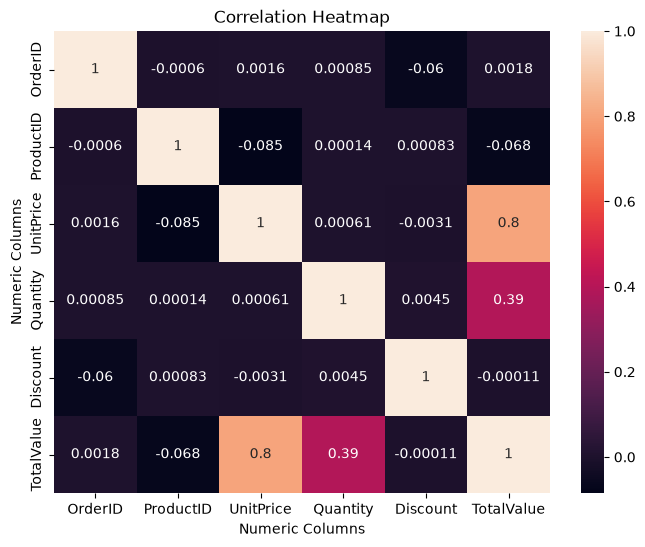

C:\Users\lokib\AppData\Local\Temp\ipykernel_1324\1698246525.py:29: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("scatter_plot.png")
C:\Users\lokib\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:158: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


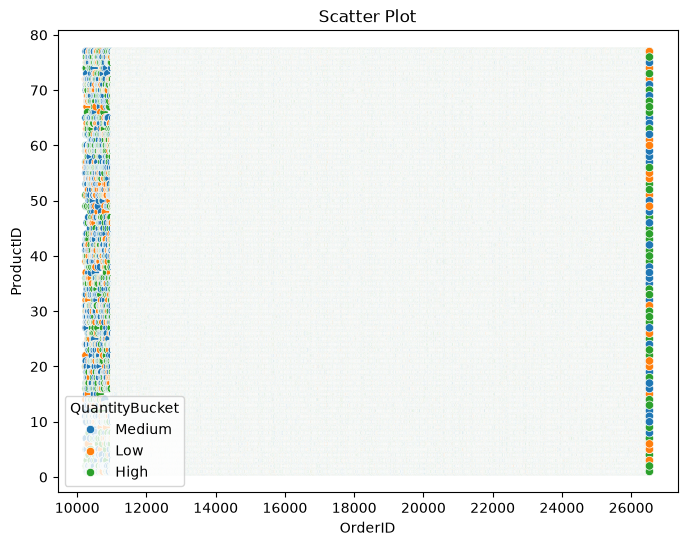

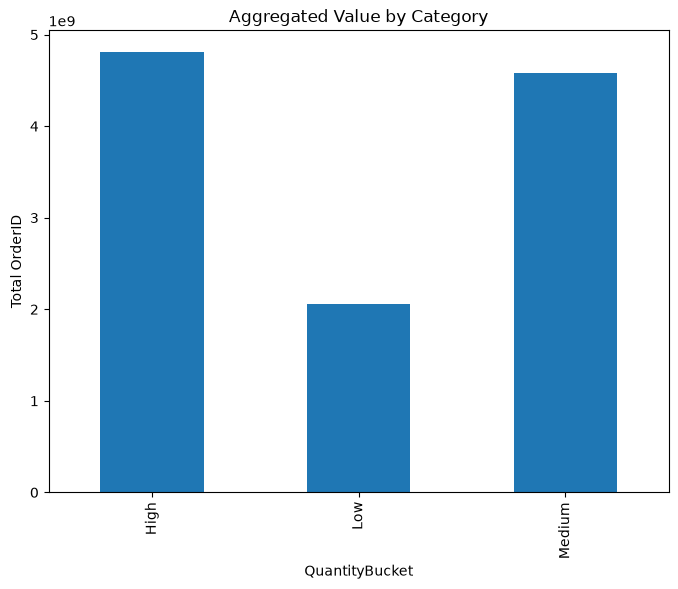

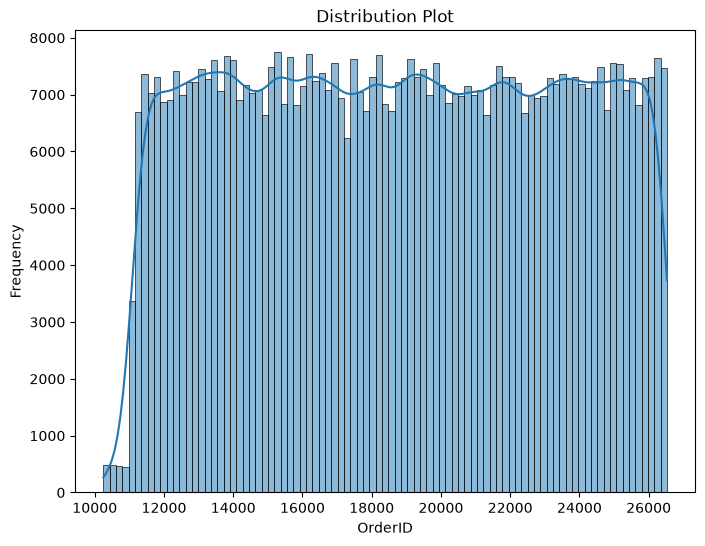

In [56]:
# Task 10: Visualizations

import seaborn as sns
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include="number").columns
cat_cols = df.select_dtypes(include="object").columns

# 1. Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.xlabel("Numeric Columns")
plt.ylabel("Numeric Columns")
plt.savefig("correlation_heatmap.png")
plt.show()

# 2. Scatter Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x=num_cols[0],
    y=num_cols[1],
    hue=cat_cols[0]
)
plt.title("Scatter Plot")
plt.xlabel(num_cols[0])
plt.ylabel(num_cols[1])
plt.savefig("scatter_plot.png")
plt.show()

# 3. Bar Plot
bar_data = df.groupby(cat_cols[0])[num_cols[0]].sum()

plt.figure(figsize=(8, 6))
bar_data.plot(kind="bar")
plt.title("Aggregated Value by Category")
plt.xlabel(cat_cols[0])
plt.ylabel(f"Total {num_cols[0]}")
plt.savefig("bar_plot.png")
plt.show()

# 4. Distribution Plot
plt.figure(figsize=(8, 6))
sns.histplot(df[num_cols[0]], kde=True)
plt.title("Distribution Plot")
plt.xlabel(num_cols[0])
plt.ylabel("Frequency")
plt.savefig("distribution_plot.png")
plt.show()

In [68]:
# Task 11: Insights → Recommendations

cat_col = df.select_dtypes(include="object").columns[0]
value_col = "TotalValue"

# Insight 1
category_total = df.groupby(cat_col)[value_col].sum()
top_category = category_total.idxmax()
top_value = category_total.max()

print("Insight 1:")
print(f"{top_category} has the highest TotalValue: {top_value:.2f}")
print("Recommendation: Focus more on this category.")

# Insight 2
corr = df.select_dtypes(include="number").corr().copy()
corr = corr.where(~np.eye(len(corr), dtype=bool))

pair = corr.abs().stack().idxmax()
highest_corr = corr.loc[pair[0], pair[1]]

print("\nInsight 2:")
print(f"{pair[0]} and {pair[1]} have correlation: {highest_corr:.2f}")
print("Recommendation: Monitor these variables together.")

# Insight 3
mean_value = df[value_col].mean()
median_value = df[value_col].median()

print("\nInsight 3:")
print(f"Mean TotalValue: {mean_value:.2f}")
print(f"Median TotalValue: {median_value:.2f}")
print("Recommendation: Use mean and median to monitor typical performance.")


C:\Users\lokib\AppData\Local\Temp\ipykernel_1324\648520424.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col = df.select_dtypes(include="object").columns[0]


Insight 1:
High has the highest TotalValue: 295720853.55
Recommendation: Focus more on this category.

Insight 2:
UnitPrice and TotalValue have correlation: 0.80
Recommendation: Monitor these variables together.

Insight 3:
Mean TotalValue: 736.07
Median TotalValue: 462.00
Recommendation: Use mean and median to monitor typical performance.
